In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## TASK 1

In [11]:
x=pd.read_csv("C:\\Users\\andrz\\Downloads\\prostate_x.txt",sep=" ")
y=pd.read_csv("C:\\Users\\andrz\\Downloads\\prostate_y.txt",sep=" ")


In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [14]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

### Cross-validation — Lasso, Ridge, Elastic Net

In [15]:
lasso = LogisticRegressionCV(
    Cs=10, cv=3, penalty='l1', solver='saga',
    scoring='accuracy', max_iter=10000, random_state=42
)
lasso.fit(x_train_scaled, y_train.values.ravel())

ridge = LogisticRegressionCV(
    Cs=10, cv=3, penalty='l2', solver='saga',
    scoring='accuracy', max_iter=10000, random_state=42
)
ridge.fit(x_train_scaled, y_train.values.ravel())

elasticnet = LogisticRegressionCV(
    Cs=10, cv=3, penalty='elasticnet', solver='saga',
    l1_ratios=[0.5], scoring='accuracy', max_iter=10000, random_state=42
)
elasticnet.fit(x_train_scaled, y_train.values.ravel())

,Cs,10
,fit_intercept,True
,cv,3
,dual,False
,penalty,'elasticnet'
,scoring,'accuracy'
,solver,'saga'
,tol,0.0001
,max_iter,10000
,class_weight,None
,n_jobs,None


In [17]:
print(f"Lasso      — best lambda: {lasso.C_[0]:.6f}  |  non-zero coefs: {np.sum(lasso.coef_ != 0)}")
print(f"Ridge      — best lambda: {ridge.C_[0]:.6f}  |  non-zero coefs: {np.sum(ridge.coef_ != 0)}")
print(f"ElasticNet — best lambda: {elasticnet.C_[0]:.6f}  |  non-zero coefs: {np.sum(elasticnet.coef_ != 0)}")

Lasso      — best lambda: 2.782559  |  non-zero coefs: 2190
Ridge      — best lambda: 0.005995  |  non-zero coefs: 6033
ElasticNet — best lambda: 0.359381  |  non-zero coefs: 268


resolved for C:0.0001
resolved for C:0.00046415888336127773
resolved for C:0.002154434690031882
resolved for C:0.01
resolved for C:0.046415888336127774
resolved for C:0.21544346900318823
resolved for C:1.0
resolved for C:4.641588833612772
resolved for C:21.54434690031882
resolved for C:100.0
resolved for C:0.0001
resolved for C:0.00046415888336127773
resolved for C:0.002154434690031882
resolved for C:0.01
resolved for C:0.046415888336127774
resolved for C:0.21544346900318823
resolved for C:1.0
resolved for C:4.641588833612772
resolved for C:21.54434690031882
resolved for C:100.0
resolved for C:0.0001
resolved for C:0.00046415888336127773
resolved for C:0.002154434690031882
resolved for C:0.01
resolved for C:0.046415888336127774
resolved for C:0.21544346900318823
resolved for C:1.0
resolved for C:4.641588833612772
resolved for C:21.54434690031882
resolved for C:100.0


C:\Users\andrz\AppData\Local\Temp\ipykernel_15544\322954583.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\andrz\anaconda3\envs\workspace\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


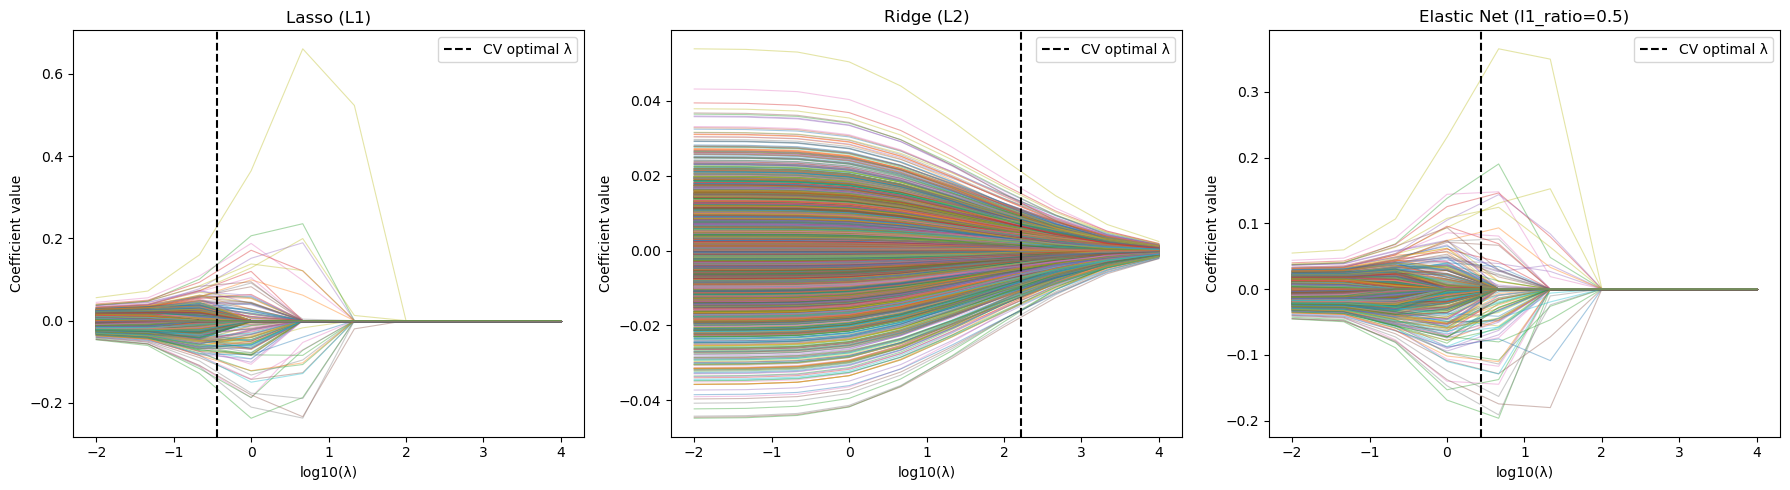

In [20]:


Cs = np.logspace(-4, 2, 10)
feature_names = x.columns.tolist()

def coef_path(penalty, solver, l1_ratio=None):
    coefs = []
    for C in Cs:
        kwargs = dict(C=C, penalty=penalty, solver=solver,
                      max_iter=10000, random_state=42)
        if l1_ratio is not None:
            kwargs['l1_ratio'] = l1_ratio
        m = LogisticRegression(**kwargs)
        m.fit(x_train_scaled, y_train.values.ravel())
        coefs.append(m.coef_[0])
        print(f"resolved for C:{C}")
    return np.array(coefs)  # shape (n_Cs, n_features)

lasso_path = coef_path('l1', 'saga')
ridge_path  = coef_path('l2', 'saga')
en_path     = coef_path('elasticnet', 'saga', l1_ratio=0.5)

lambdas = 1.0 / Cs  # convert C -> lambda

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net (l1_ratio=0.5)']
paths  = [lasso_path, ridge_path, en_path]

for ax, path, title in zip(axes, paths, titles):
    for j in range(path.shape[1]):
        ax.plot(np.log10(lambdas), path[:, j], alpha=0.4, linewidth=0.8)
    ax.axvline(x=np.log10(1.0 / lasso.C_[0]) if 'Lasso' in title
               else (np.log10(1.0 / ridge.C_[0]) if 'Ridge' in title
               else np.log10(1.0 / elasticnet.C_[0])),
               color='black', linestyle='--', label='CV optimal λ')
    ax.set_xlabel('log10(λ)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('profile_plots.png', dpi=120)
plt.show()

In [21]:
y_test_flat = y_test.values.ravel()

for name, model in [('Lasso', lasso), ('Ridge', ridge), ('ElasticNet', elasticnet)]:
    acc  = accuracy_score(y_test_flat, model.predict(x_test_scaled))
    nz   = np.sum(model.coef_ != 0)
    best_C = model.C_[0]
    print(f"{name:12s} | best C={best_C:.5f} (λ={1/best_C:.5f}) "
          f"| non-zero coefs: {nz:4d} / {model.coef_.shape[1]} "
          f"| test accuracy: {acc:.4f}")

Lasso        | best C=2.78256 (λ=0.35938) | non-zero coefs: 2190 / 6033 | test accuracy: 0.9524
Ridge        | best C=0.00599 (λ=166.81005) | non-zero coefs: 6033 / 6033 | test accuracy: 0.9048
ElasticNet   | best C=0.35938 (λ=2.78256) | non-zero coefs:  268 / 6033 | test accuracy: 0.9524


## TASK 2 — Performance of Lasso for Simulated Data

In [2]:
def generate_logistic(n, irrelevant_features=10, probit=False):
    p_features = 10 + irrelevant_features
    X = np.random.normal(0, 1, size=(n, p_features))
    beta = np.array([1.0] * 10 + [0.0] * irrelevant_features)
    linear = X @ beta          # β^T x_i  (intercept = 0)
    if probit:
        from scipy.stats import norm
        prob = norm.cdf(linear)
    else:
        prob = 1.0 / (1.0 + np.exp(-linear))
    y = np.random.binomial(1, prob, n)
    return X, y

In [3]:
def fit_lasso_and_metrics(X, y, true_relevant_idx):
    scaler_loc = StandardScaler()
    X_sc = scaler_loc.fit_transform(X)
    model = LogisticRegressionCV(
        Cs=10, cv=5, penalty='l1', solver='saga',
        scoring='accuracy', max_iter=10000, random_state=42
    )
    model.fit(X_sc, y)
    selected = set(np.where(model.coef_[0] != 0)[0])
    true_set = set(true_relevant_idx)
    tp = len(selected & true_set)
    psr = tp / len(true_set) if len(true_set) > 0 else 0.0
    fdr = (len(selected) - tp) / len(selected) if len(selected) > 0 else 0.0
    return psr, fdr

In [27]:
np.random.seed(0)
X_demo, y_demo = generate_logistic(n=300)
psr_demo, fdr_demo = fit_lasso_and_metrics(X_demo, y_demo, true_relevant_idx=list(range(10)))
print(f"Demo run — PSR: {psr_demo:.3f}  |  FDR: {fdr_demo:.3f}")

Demo run — PSR: 1.000  |  FDR: 0.375


n=   50  PSR=0.842  FDR=0.383
n=  100  PSR=0.985  FDR=0.395
n=  300  PSR=1.000  FDR=0.423
n=  500  PSR=1.000  FDR=0.416
n= 1000  PSR=1.000  FDR=0.302
n= 2000  PSR=1.000  FDR=0.270


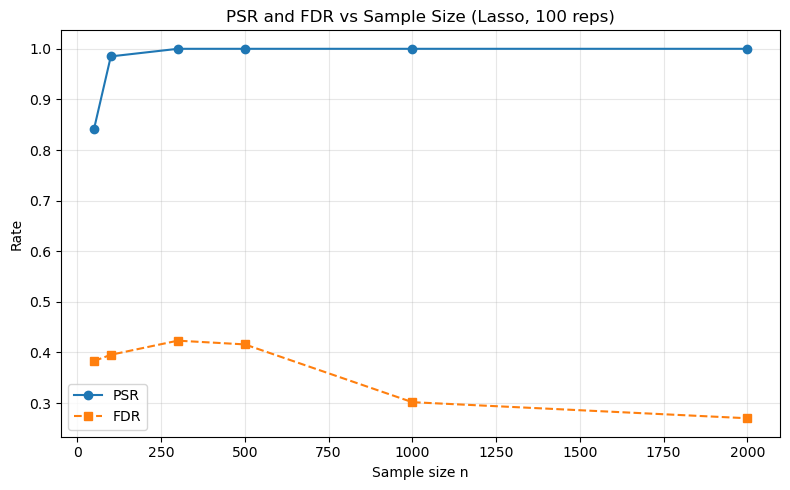

In [28]:
L = 100
sample_sizes = [50, 100, 300, 500, 1000, 2000]
true_idx = list(range(10))

psr_by_n, fdr_by_n = [], []

for n in sample_sizes:
    psrs, fdrs = [], []
    for _ in range(L):
        X_s, y_s = generate_logistic(n, irrelevant_features=10)
        p, f = fit_lasso_and_metrics(X_s, y_s, true_idx)
        psrs.append(p); fdrs.append(f)
    psr_by_n.append(np.mean(psrs))
    fdr_by_n.append(np.mean(fdrs))
    print(f"n={n:5d}  PSR={np.mean(psrs):.3f}  FDR={np.mean(fdrs):.3f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, psr_by_n, 'o-', label='PSR')
plt.plot(sample_sizes, fdr_by_n, 's--', label='FDR')
plt.xlabel('Sample size n')
plt.ylabel('Rate')
plt.title('PSR and FDR vs Sample Size (Lasso, 100 reps)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('psr_fdr_vs_n.png', dpi=120)
plt.show()

In [ ]:
n_fixed = 300
irrelevant_counts = [10, 50, 100, 200, 500]

psr_by_irr, fdr_by_irr = [], []

for irr in irrelevant_counts:
    psrs, fdrs = [], []
    for _ in range(L):
        X_s, y_s = generate_logistic(n_fixed, irrelevant_features=irr)
        p, f = fit_lasso_and_metrics(X_s, y_s, true_idx)
        psrs.append(p); fdrs.append(f)
    psr_by_irr.append(np.mean(psrs))
    fdr_by_irr.append(np.mean(fdrs))
    print(f"irr={irr:4d}  PSR={np.mean(psrs):.3f}  FDR={np.mean(fdrs):.3f}")

plt.figure(figsize=(8, 5))
plt.plot(irrelevant_counts, psr_by_irr, 'o-', label='PSR')
plt.plot(irrelevant_counts, fdr_by_irr, 's--', label='FDR')
plt.xlabel('Number of irrelevant features')
plt.ylabel('Rate')
plt.title('PSR and FDR vs # Irrelevant Features (n=300, 100 reps)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('psr_fdr_vs_irrelevant.png', dpi=120)
plt.show()

irr=  10  PSR=1.000  FDR=0.411


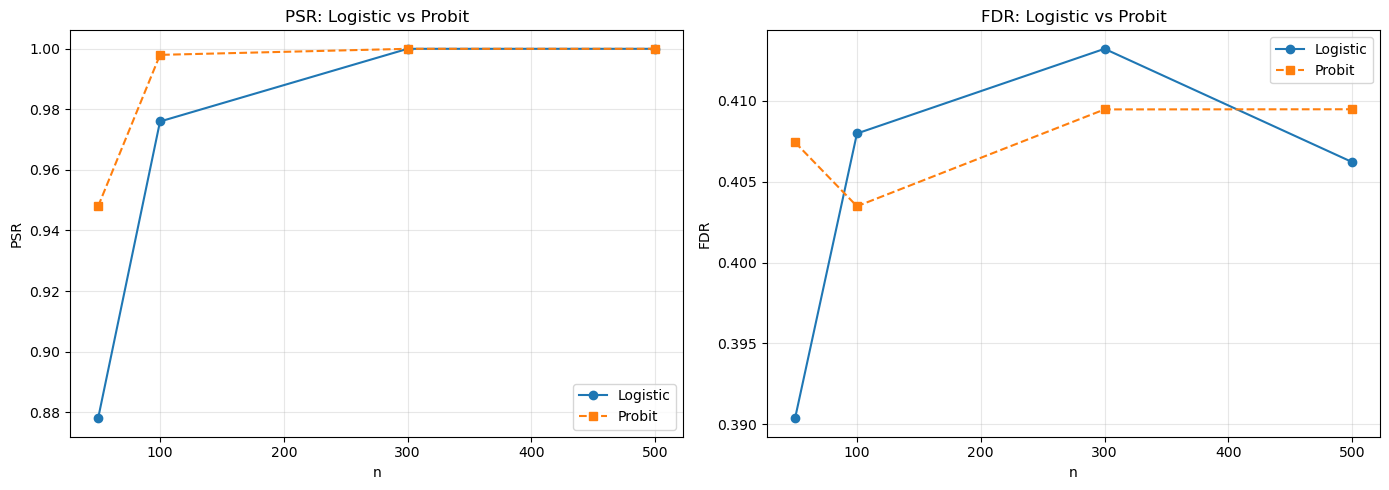

In [5]:
psr_probit_by_n, fdr_probit_by_n = [], []
psr_logit_by_n,  fdr_logit_by_n  = [], []
L = 50
sample_sizes = [50, 100, 300, 500]
true_idx = list(range(10))
for n in sample_sizes:
    psrs_l, fdrs_l, psrs_p, fdrs_p = [], [], [], []
    for _ in range(L):
        # logistic
        X_s, y_s = generate_logistic(n, probit=False)
        p, f = fit_lasso_and_metrics(X_s, y_s, true_idx)
        psrs_l.append(p); fdrs_l.append(f)
        # probit
        X_s, y_s = generate_logistic(n, probit=True)
        p, f = fit_lasso_and_metrics(X_s, y_s, true_idx)
        psrs_p.append(p); fdrs_p.append(f)
    psr_logit_by_n.append(np.mean(psrs_l));  fdr_logit_by_n.append(np.mean(fdrs_l))
    psr_probit_by_n.append(np.mean(psrs_p)); fdr_probit_by_n.append(np.mean(fdrs_p))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sample_sizes, psr_logit_by_n,  'o-',  label='Logistic')
axes[0].plot(sample_sizes, psr_probit_by_n, 's--', label='Probit')
axes[0].set_xlabel('n'); axes[0].set_ylabel('PSR')
axes[0].set_title('PSR: Logistic vs Probit'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sample_sizes, fdr_logit_by_n,  'o-',  label='Logistic')
axes[1].plot(sample_sizes, fdr_probit_by_n, 's--', label='Probit')
axes[1].set_xlabel('n'); axes[1].set_ylabel('FDR')
axes[1].set_title('FDR: Logistic vs Probit'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_vs_probit.png', dpi=120)
plt.show()

## Comments

**Task 1 — Comparison of regularization methods**

- **Lasso (L1)** sets many coefficients exactly to zero — it performs automatic variable selection and produces the sparsest model. In a high-dimensional gene-expression setting this means only a small number of genes are retained.
- **Ridge (L2)** shrinks all coefficients toward zero but never sets them exactly to zero. Correlated predictors are kept together with similar (shrunk) weights. Useful for prediction but not for variable selection.
- **Elastic Net** interpolates between the two: the L1 component drives sparsity while the L2 component groups correlated variables, addressing the *lasso instability* when features are highly correlated. In the gene expression data it turns out that it selects even less variables for optimal λ, though it should be noticed that the value of λ selected by elastic net is much higher than that in pure lasso.
- The λ selected by cross-validation optimises **predictive accuracy**, not variable selection quality. A slightly larger λ ("lambda.1se" in R's glmnet convention) may yield a sparser, more interpretable model at minimal cost in accuracy.

**Task 2 — PSR and FDR**

- **PSR** measures *recall* among the true relevant variables: how many of the 10 real signals did the model find?
- **FDR** measures the *false alarm rate* among selected variables: what fraction of what the model flagged is actually noise?
- A model can have high predictive accuracy but low PSR (missing signals absorbed into the intercept) or high FDR (noise variables correlated with the response by chance). These two metrics capture complementary failure modes.
- As n grows, both PSR ↑ and FDR ↓, confirming the consistency of lasso under appropriate conditions.
- More irrelevant features increase FDR (more candidates for false selection) while PSR is less affected, especially with adequate n.
- Under **probit** data generation, fitting a *logistic* lasso still identifies most relevant variables (PSR is similar), since both link functions are monotone and smooth. FDR is higher for small  and large n, though for the middle values of n it is lower. The difference at higher n values are small, so overall robustness seems to be good.
